# Proyecto de Ajuste Fino (Fine-tuning) Multi-Tarea

Este notebook presenta un flujo de trabajo completo para el entrenamiento, evaluación y exportación de tres modelos de procesamiento de lenguaje natural (NLP) utilizando la librería `transformers` de Hugging Face.

## Modelos y Tareas

1.  **Clasificación de Intenciones**: Uso de BERT para identificar propósitos en textos de usuarios.
2.  **Reconocimiento de Entidades Nombradas (NER)**: Etiquetado de secuencias para identificar personas, lugares y organizaciones.
3.  **Traducción Automática**: Un modelo Seq2Seq para traducir texto de alemán a inglés.

## Estructura del Notebook
- **Configuración**: Instalación de dependencias y carga de librerías.
- **Análisis de Datos (EDA)**: Exploración de los datasets utilizados.
- **Entrenamiento**: Proceso de fine-tuning para cada tarea específica.
- **Exportación**: Compresión y descarga de los modelos listos para producción.

In [ ]:
# 1. Instalación de dependencias del sistema
import os
import sys

def instalar_librerias():
    """
    Instala todas las librerías necesarias de forma silenciosa.
    Maneja errores básicos de instalación.
    """
    print("--- Iniciando instalación de dependencias ---")
    try:
        # Instalamos versiones específicas para asegurar compatibilidad
        !pip install -q transformers==4.43.0 datasets evaluate seqeval sacrebleu sentencepiece
        print("Todas las librerías se instalaron correctamente.")
    except Exception as e:
        print(f"Error durante la instalación: {e}", file=sys.stderr)

instalar_librerias()

In [ ]:
# 2. Importaciones globales y configuración del entorno
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import warnings
from functools import partial
from google.colab import files
from datasets import load_dataset, Dataset
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    AutoModelForSeq2SeqLM,
    TrainingArguments,
    Trainer,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorWithPadding,
    DataCollatorForTokenClassification,
    DataCollatorForSeq2Seq,
    IntervalStrategy,
    pipeline
)
import evaluate

# Configuración de estilo para gráficas
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Desactivar advertencias innecesarias de Transformers
warnings.filterwarnings("ignore", category=UserWarning)

# Configuración de CUDA para depuración y rendimiento
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

print("✅ Entorno configurado: GPU disponible: ", torch.cuda.is_available())

#Dataset Sequence-Classification
url: https://huggingface.co/datasets/yuweiyin/IntentGrasp

#Dataset Sequence-Labeling
url: https://huggingface.co/datasets/Davlan/conll2003_noMISC

#Dataset Sequence2Senquence
url: https://huggingface.co/datasets/wmt/wmt16

## Descripción detallada del conjunto de datos y análisis exploratorio de datos

Esta sección ofrece una descripción detallada de cada conjunto de datos que se utilizará en el proyecto, incluyendo su dominio del problema, utilidad, datos de entrada, variable de salida y tipo de problema. Tras la descripción, se realizará un análisis exploratorio de datos (AED), con ejemplos que facilitarán la comprensión del problema abordado.

### Conjunto de datos 1: Clasificación de secuencias (IntentGrasp)

* **Dominio del problema**: Comprensión del lenguaje natural (PLN), específicamente, clasificación de intenciones.

* **Utilidad**: Este conjunto de datos se utiliza para entrenar modelos que pueden identificar la intención del usuario a partir de un texto. Esto es crucial para que la IA conversacional, los chatbots y los asistentes virtuales comprendan las solicitudes del usuario y las gestionen adecuadamente.

* **Datos de entrada**: Una cadena de texto que representa la consulta o el comando del usuario.

* **Variable de salida**: Una etiqueta categórica que representa la intención detectada (p. ej., 'Reproducir música', 'Reservar vuelo', 'Configurar alarma').

* **Tipo de problema**: Clasificación de texto multicategoría (o, más específicamente, clasificación de secuencias, ya que clasifica la secuencia completa de palabras).

Carguemos el conjunto de datos y realicemos un análisis exploratorio.

Loading IntentGrasp dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

all/train.parquet:   0%|          | 0.00/44.5M [00:00<?, ?B/s]

all/test.parquet:   0%|          | 0.00/3.79M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/262759 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12909 [00:00<?, ? examples/s]

Dataset loaded successfully.
Number of samples: 262759
Features: {'id': Value('string'), 'metadata': {'id': Value('string'), 'paper_year': Value('int64'), 'original_task': Value('string'), 'original_split': Value('string'), 'text_form': Value('string'), 'intent_type': Value('string'), 'is_synthetic': Value('bool'), 'is_sensitive': Value('bool'), 'domain_topic': List(List(Value('string')))}, 'speaker': Value('string'), 'context': Value('string'), 'question': Value('string'), 'options': List(Value('string')), 'answer_intent': List(Value('string')), 'answer_index': List(Value('int64'))}

First 5 examples:
  Text: user: i want to fly from boston at 838 am and arrive in denver at 1110 in the morning
  Label: ['To book flights or ask for general flight information.']
  Text: user: what flights are available from pittsburgh to baltimore on thursday morning
  Label: ['To book flights or ask for general flight information.']
  Text: user: what is the arrival time in san francisco for the 755 am

/tmp/ipykernel_3667/2531532334.py:30: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3667/2531532334.py:30: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipykernel_3667/2531532334.py:30: UserWarning: Glyph 2467 (\N{BENGALI LETTER NNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3667/2531532334.py:30: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3667/2531532334.py:30: UserWarning: Glyph 2479 (\N{BENGALI LETTER YA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3667/2531532334.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2474 (\N{BENGALI LETTER 

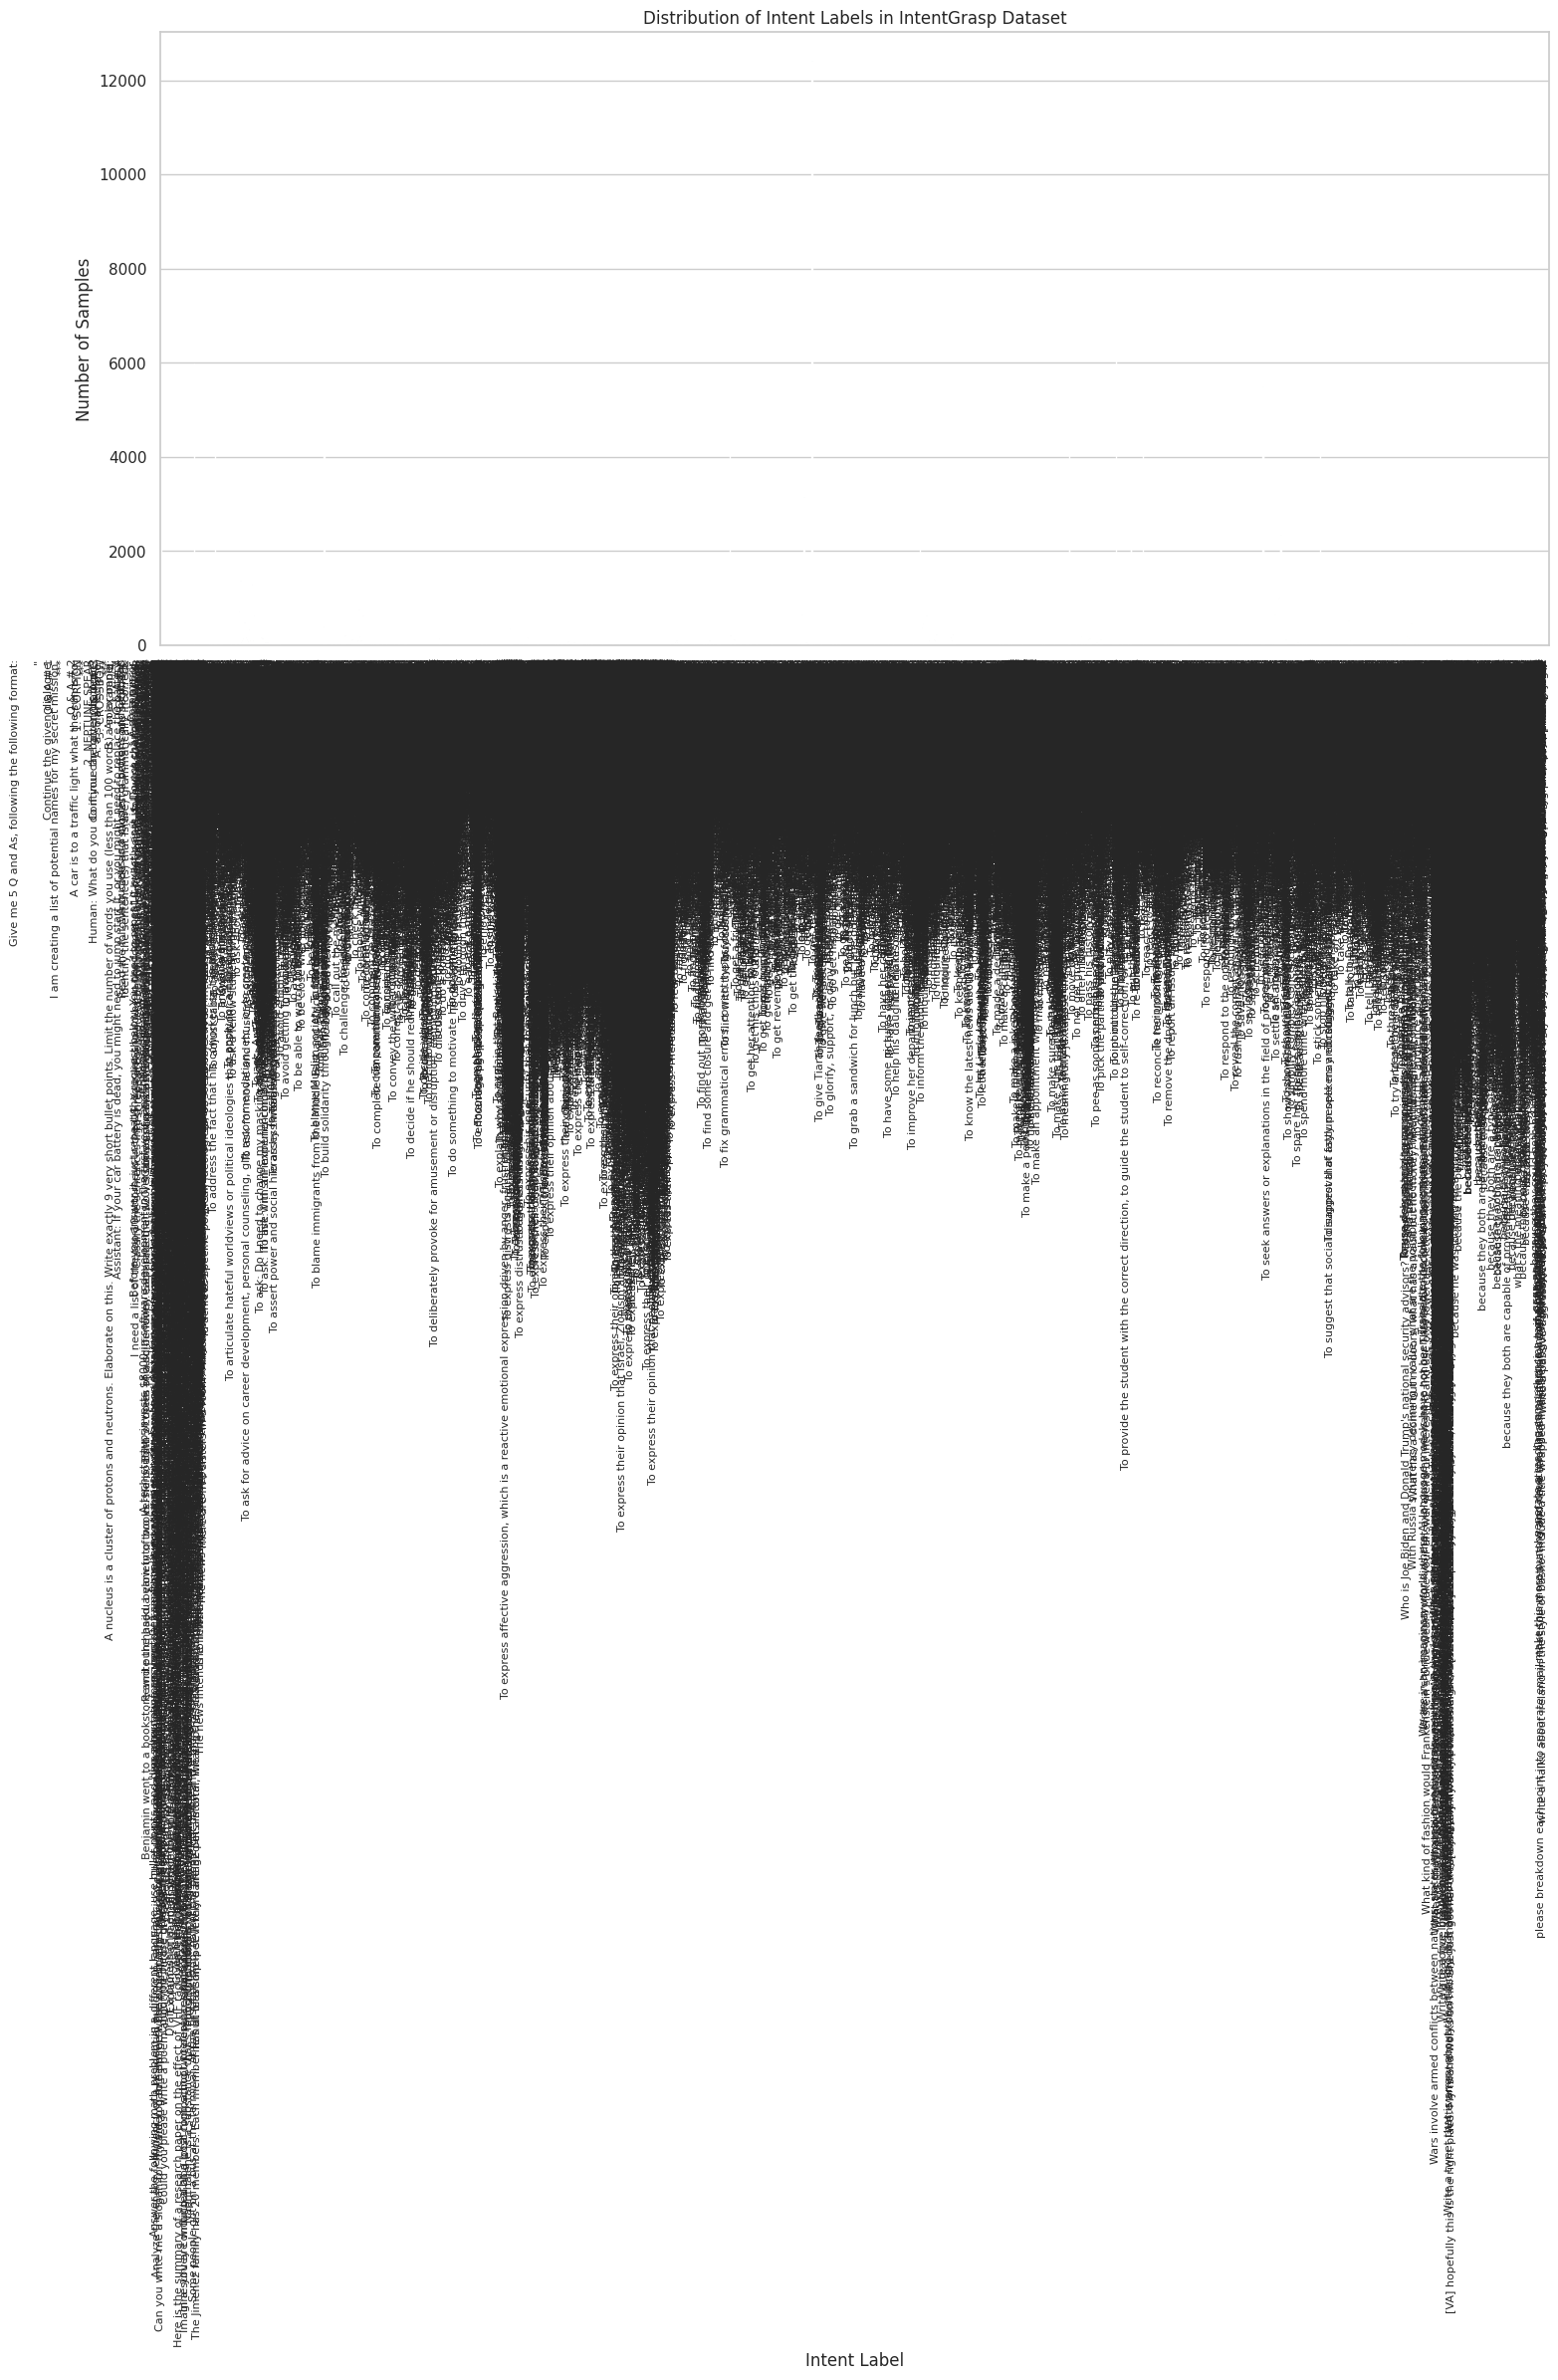

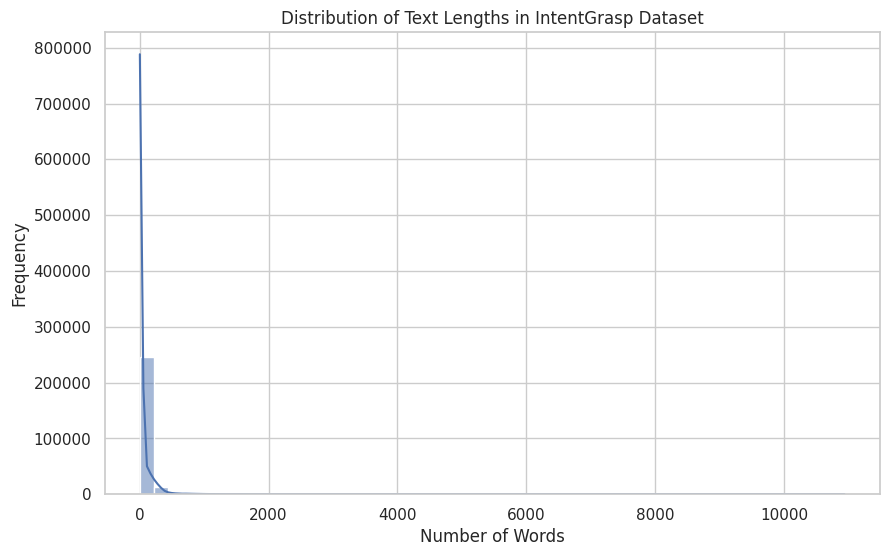

In [3]:
def analizar_dataset_intenciones(dataset_name='yuweiyin/IntentGrasp'):
    """
    Carga, procesa y visualiza la distribución de intenciones y longitudes de texto.
    """
    print(f"Cargando dataset: {dataset_name}...")
    try:
        dataset = load_dataset(dataset_name, 'all', split='train')
        print("Dataset cargado correctamente.")
    except Exception as e:
        print(f"Error al cargar el dataset: {e}")
        return None

    # Mostrar información básica
    print(f"Cantidad de muestras: {len(dataset)}")

    # Visualizar ejemplos
    print("\nPrimeros 5 ejemplos:")
    for i in range(5):
        print(f"  Texto: {dataset[i]['context']}")
        print(f"  Intención: {dataset[i]['answer_intent']}")

    # Procesamiento de etiquetas
    # 'answer_intent' es una lista de cadenas, usamos explode para individualizarlas
    todas_intenciones = pd.Series(dataset['answer_intent']).explode()
    nombres_etiquetas = todas_intenciones.unique().tolist()
    print(f"\nIntenciones únicas detectadas: {len(nombres_etiquetas)}")

    # Visualización 1: Distribución de etiquetas
    conteos = todas_intenciones.value_counts().sort_index()
    df_etiquetas = pd.DataFrame({'nombre': conteos.index, 'cantidad': conteos.values})

    plt.figure(figsize=(18, 8))
    sns.barplot(x='nombre', y='cantidad', data=df_etiquetas, palette='viridis', hue='nombre', legend=False)
    plt.title('Distribución de Intenciones en el Dataset IntentGrasp')
    plt.xlabel('Etiqueta de Intención')
    plt.ylabel('Número de Muestras')
    plt.xticks(rotation=90, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

    # Visualización 2: Longitud de los textos (palabras)
    longitudes = [len(ejemplo['context'].split()) for ejemplo in dataset]
    plt.figure(figsize=(10, 6))
    sns.histplot(longitudes, bins=50, kde=True, color='skyblue')
    plt.title('Distribución de la Longitud de los Textos')
    plt.xlabel('Número de Palabras')
    plt.ylabel('Frecuencia')
    plt.show()

    return dataset

# Ejecutar análisis
intent_grasp_dataset = analizar_dataset_intenciones()

In [4]:
def preparar_etiquetas_clasificacion(dataset):
    """
    Convierte la lista de intenciones en una sola cadena y crea mapeos numéricos.
    """
    def unificar_intenciones(ejemplo):
        if isinstance(ejemplo['answer_intent'], list):
            return {"answer_intent": ", ".join(ejemplo["answer_intent"])}
        return ejemplo

    print("Procesando etiquetas de intención...")
    dataset = dataset.map(unificar_intenciones)

    # Extraer etiquetas únicas y crear mapeos
    intenciones_unicas = sorted(list(set([ex['answer_intent'] for ex in dataset])))
    label2id = {label: i for i, label in enumerate(intenciones_unicas)}
    id2label = {i: label for i, label in enumerate(intenciones_unicas)}

    return dataset, label2id, id2label

intent_grasp_dataset, label2id_map, id2label_map = preparar_etiquetas_clasificacion(intent_grasp_dataset)

Map:   0%|          | 0/262759 [00:00<?, ? examples/s]

Number of unique intents (after joining multi-intents): 18497
Label to ID map and ID to Label map created.


### Conjunto de datos 2: Etiquetado de secuencias (conll2003_noMISC)

* **Dominio del problema**: Reconocimiento de entidades nombradas (NER).

* **Utilidad**: Este conjunto de datos se utiliza para entrenar modelos que pueden identificar y clasificar entidades nombradas (como personas, organizaciones, lugares) dentro de un texto. Esto es fundamental para la extracción de información, los motores de búsqueda, los sistemas de respuesta a preguntas y más.

* **Datos de entrada**: Una secuencia de palabras (una oración).

* **Variable de salida**: Una secuencia de etiquetas, donde cada etiqueta corresponde a una palabra en la secuencia de entrada, indicando si la palabra forma parte de una entidad nombrada y su tipo (por ejemplo, 'B-PER' para el inicio del nombre de una persona, 'I-LOC' para dentro del nombre de un lugar, 'O' para fuera de cualquier entidad).

* **Tipo de problema**: Etiquetado de secuencias.

Carguemos el conjunto de datos y examinemos su estructura y algunos ejemplos.

Loading conll2003_noMISC dataset...


train.json: 0.00B [00:00, ?B/s]

dev.json: 0.00B [00:00, ?B/s]

test.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Dataset loaded successfully.
Number of samples: 14041
Features: {'tokens': List(Value('string')), 'ner_tags': List(Value('string'))}

First 3 examples:
  Words: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
  NER Tags: ['B-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
  Words: ['Peter', 'Blackburn']
  NER Tags: ['B-PER', 'I-PER']
  Words: ['BRUSSELS', '1996-08-22']
  NER Tags: ['B-LOC', 'O']

Unique NER Tag names: ['B-LOC', 'B-ORG', 'B-PER', 'I-LOC', 'I-ORG', 'I-PER', 'O']


/tmp/ipykernel_3667/1952974578.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tag_name', y='count', data=ner_tag_df, palette='viridis')


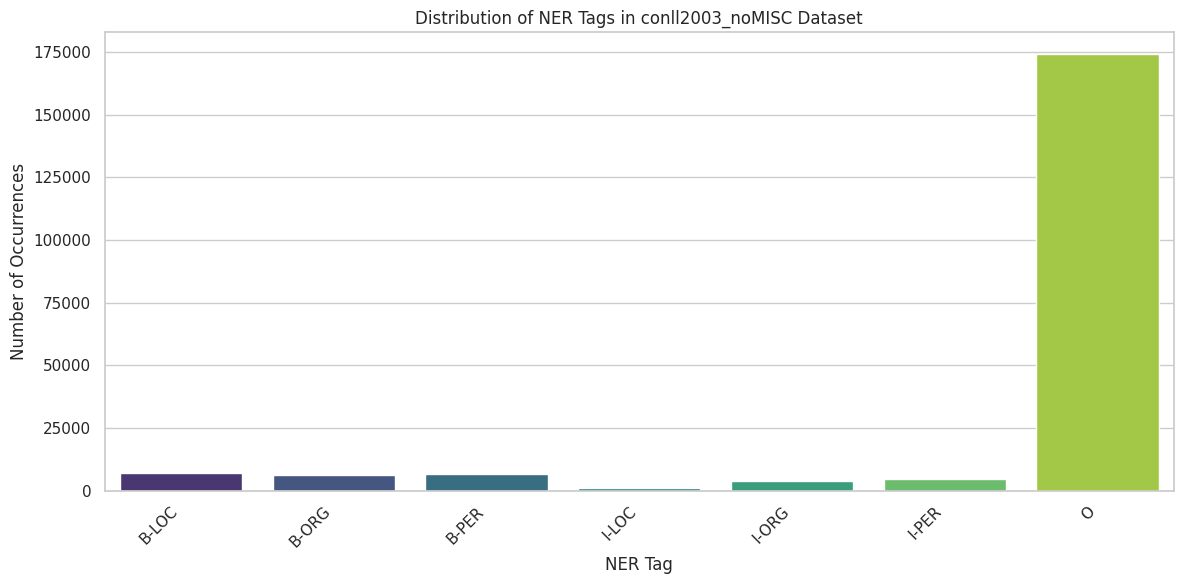

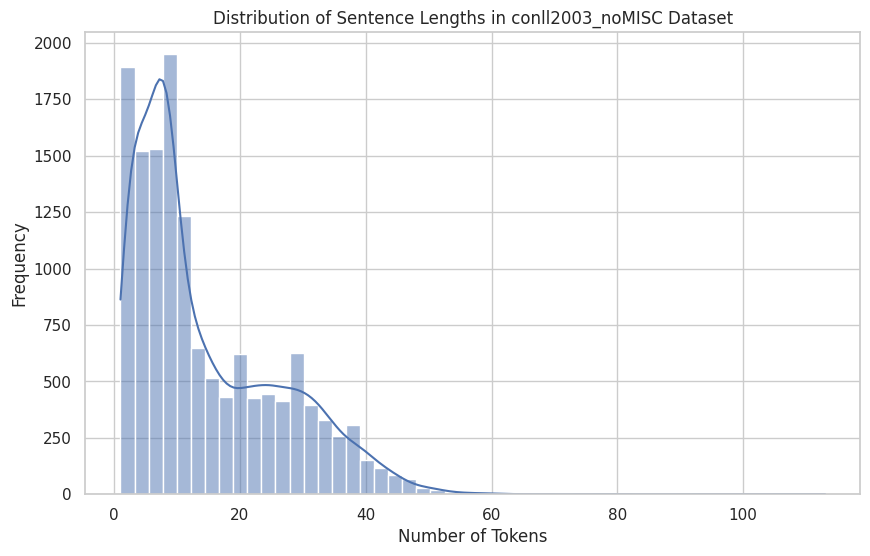

In [17]:
def analizar_dataset_ner(dataset_name='Davlan/conll2003_noMISC'):
    """
    Carga, analiza y visualiza la distribución de etiquetas NER y longitudes de oraciones.
    """
    print(f"Cargando dataset NER: {dataset_name}...")
    try:
        dataset = load_dataset(dataset_name, split='train')
        print("Dataset NER cargado correctamente.")
    except Exception as e:
        print(f"Error al cargar el dataset NER: {e}")
        return None

    # Mostrar información básica
    print(f"Cantidad de muestras: {len(dataset)}")

    # Visualizar ejemplos
    print("\nPrimeros 3 ejemplos:")
    for i in range(3):
        print(f"  Palabras: {dataset[i]['tokens']}")
        print(f"  Etiquetas NER: {dataset[i]['ner_tags']}")

    # Extraer nombres de etiquetas únicas
    todas_etiquetas_planas = [tag for ejemplo in dataset for tag in ejemplo['ner_tags']]
    nombres_etiquetas_ner = sorted(list(set(todas_etiquetas_planas)))
    print(f"\nEtiquetas NER únicas detectadas: {nombres_etiquetas_ner}")

    # Visualización 1: Distribución de etiquetas
    conteos_ner = pd.Series(todas_etiquetas_planas).value_counts().sort_index()
    df_ner = pd.DataFrame({'etiqueta': conteos_ner.index, 'cantidad': conteos_ner.values})

    plt.figure(figsize=(12, 6))
    sns.barplot(x='etiqueta', y='cantidad', data=df_ner, palette='magma', hue='etiqueta', legend=False)
    plt.title('Distribución de Etiquetas NER (conll2003_noMISC)')
    plt.xlabel('Tipo de Entidad')
    plt.ylabel('Frecuencia de Aparición')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Visualización 2: Longitud de oraciones
    longitudes_ner = [len(ejemplo['tokens']) for ejemplo in dataset]
    plt.figure(figsize=(10, 6))
    sns.histplot(longitudes_ner, bins=50, kde=True, color='salmon')
    plt.title('Distribución de la Longitud de Oraciones (Tokens)')
    plt.xlabel('Número de Tokens')
    plt.ylabel('Frecuencia')
    plt.show()

    return dataset, nombres_etiquetas_ner

# Ejecutar análisis y actualizar variables globales
conll_dataset, ner_tag_names = analizar_dataset_ner()

### Conjunto de datos 3: Secuencia a secuencia (WMT16 - Alemán-Inglés)

* **Ámbito del problema**: Traducción automática.

* **Utilidad**: Este conjunto de datos está diseñado para entrenar y evaluar modelos que traducen texto de un idioma (alemán) a otro (inglés). Es fundamental para el desarrollo de herramientas de comunicación multilingües.

* **Datos de entrada**: Una oración en el idioma de origen (alemán).

* **Variable de salida**: Una oración en el idioma de destino (inglés).

* **Tipo de problema**: Generación de secuencia a secuencia, específicamente traducción automática neuronal.

Carguemos la versión alemán-inglés del conjunto de datos WMT16 e inspeccionemos algunos pares de traducción.

Loading WMT16 (de-en) dataset...


README.md: 0.00B [00:00, ?B/s]

de-en/train-00000-of-00003.parquet:   0%|          | 0.00/282M [00:00<?, ?B/s]

de-en/train-00001-of-00003.parquet:   0%|          | 0.00/267M [00:00<?, ?B/s]

de-en/train-00002-of-00003.parquet:   0%|          | 0.00/277M [00:00<?, ?B/s]

...

de-en/test-00000-of-00001.parquet:   0%|          | 0.00/475k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4548885 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2169 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2999 [00:00<?, ? examples/s]

Dataset loaded successfully.
Number of samples: 4548885
Features: {'translation': Translation(languages=['de', 'en'])}

First 5 translation examples:
  German: Wiederaufnahme der Sitzungsperiode
  English: Resumption of the session
  German: Ich erkläre die am Freitag, dem 17. Dezember unterbrochene Sitzungsperiode des Europäischen Parlaments für wiederaufgenommen, wünsche Ihnen nochmals alles Gute zum Jahreswechsel und hoffe, daß Sie schöne Ferien hatten.
  English: I declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I would like once again to wish you a happy new year in the hope that you enjoyed a pleasant festive period.
  German: Wie Sie feststellen konnten, ist der gefürchtete "Millenium-Bug " nicht eingetreten. Doch sind Bürger einiger unserer Mitgliedstaaten Opfer von schrecklichen Naturkatastrophen geworden.
  English: Although, as you will have seen, the dreaded 'millennium bug' failed to materialise, still the people in a number

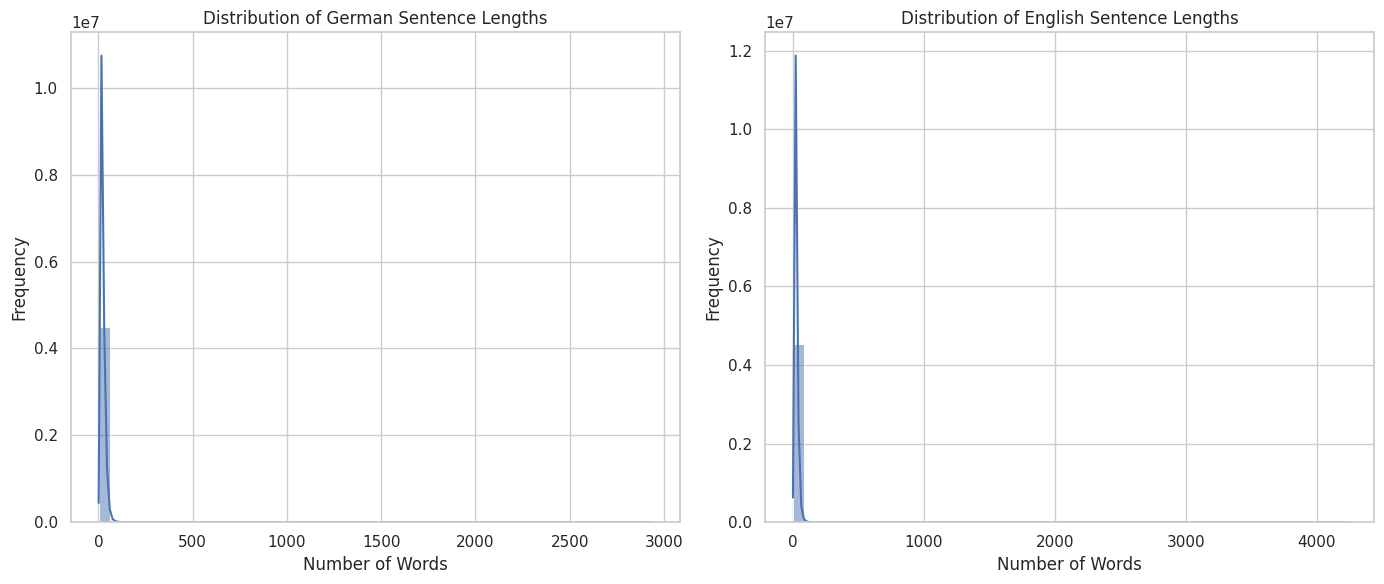

In [34]:
def analizar_dataset_traduccion(dataset_name='wmt16', subset='de-en'):
    """
    Carga y analiza el dataset de traducción, comparando las longitudes de las oraciones en ambos idiomas.
    """
    print(f"Cargando dataset de traducción {subset}...")
    try:
        dataset = load_dataset(dataset_name, subset, split='train')
        print("Dataset de traducción cargado correctamente.")
    except Exception as e:
        print(f"Error al cargar el dataset de traducción: {e}")
        return None

    # Mostrar información básica
    print(f"Cantidad total de pares de traducción: {len(dataset)}")

    # Visualizar ejemplos
    print("\nPrimeros 5 ejemplos de traducción:")
    for i in range(5):
        print(f"  [DE]: {dataset[i]['translation']['de']}")
        print(f"  [EN]: {dataset[i]['translation']['en']}\n")

    # Calcular longitudes de oraciones
    print("Calculando estadísticas de longitud...")
    longitudes_de = [len(ex['translation']['de'].split()) for ex in dataset]
    longitudes_en = [len(ex['translation']['en'].split()) for ex in dataset]

    # Visualización comparativa
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    sns.histplot(longitudes_de, bins=50, kde=True, color='teal')
    plt.title('Distribución de Longitud: Alemán (DE)')
    plt.xlabel('Número de Palabras')
    plt.ylabel('Frecuencia')

    plt.subplot(1, 2, 2)
    sns.histplot(longitudes_en, bins=50, kde=True, color='orange')
    plt.title('Distribución de Longitud: Inglés (EN)')
    plt.xlabel('Número de Palabras')
    plt.ylabel('Frecuencia')

    plt.tight_layout()
    plt.show()

    return dataset

# Ejecutar análisis del tercer dataset
wmt_dataset = analizar_dataset_traduccion()

## Mejores modelos para cada problema mediante ajuste fino con Hugging Face

Al elegir un modelo para el ajuste fino en Hugging Face, entran en juego varios factores, como la tarea específica, el tamaño del conjunto de datos, los recursos computacionales y el rendimiento deseado. Aquí, recomendaré modelos populares y eficaces para cada uno de los tipos de problemas mostrados anteriormente.

### 1. Clasificación de secuencias (IntentGrasp)

Para tareas de clasificación de secuencias, como el reconocimiento de intenciones, modelos como **BERT, RoBERTa o DistilBERT** son excelentes opciones. Están preentrenados con grandes corpus para comprender el contexto lingüístico y pueden ajustarse con un módulo de clasificación para tareas específicas. **bert-base-uncased** es un modelo robusto y de uso general.

A continuación, se muestra cómo cargar el tokenizador y el modelo para la clasificación de secuencias:

In [5]:
def cargar_modelo_clasificacion(model_name='bert-base-uncased', num_labels=None):
    """
    Carga el tokenizador y el modelo BERT para clasificación de secuencias.
    """
    print(f"Cargando tokenizador y modelo para Clasificación: {model_name}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Cargamos el modelo con el número de etiquetas detectadas
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )

    print("Modelo y tokenizador de clasificación cargados correctamente.")
    print(f"Arquitectura: {model.__class__.__name__}")
    print(f"Etiquetas en la cabecera: {model.config.num_labels}")

    return tokenizer, model

# Determinar número de etiquetas únicas del dataset analizado anteriormente
num_intenciones = len(id2label_map)
classification_tokenizer, classification_model = cargar_modelo_clasificacion(num_labels=num_intenciones)

# Configurar los mapeos en la configuración del modelo
classification_model.config.id2label = id2label_map
classification_model.config.label2id = label2id_map

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Loading tokenizer and model for Sequence Classification: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

Sequence Classification Model and Tokenizer loaded successfully.
Model Architecture: BertForSequenceClassification
Number of labels in classification head (corrected): 18497


### 2. Etiquetado de secuencias (conll2003_noMISC)

Para tareas de etiquetado de secuencias como el Reconocimiento de Entidades Nombradas (NER), se requieren modelos con un cabezal de clasificación de tokens. **BERT, RoBERTa o ELECTRA** son comúnmente utilizados. **bert-base-uncased** también es una buena opción de referencia, adaptada con un cabezal específico para predicciones a nivel de token.

A continuación, se muestra cómo cargar el tokenizador y el modelo para el etiquetado de secuencias. Tenga en cuenta que pasamos `id2label` y `label2id` para configurar el cabezal de salida con las etiquetas NER específicas.

In [19]:
def cargar_modelo_ner(model_name='bert-base-uncased', etiquetas=None):
    """
    Configura y carga el modelo BERT para el etiquetado de tokens (NER).
    """
    print(f"Cargando tokenizador y modelo para NER: {model_name}")

    # Crear mapeos bidireccionales
    label2id = {label: i for i, label in enumerate(etiquetas)}
    id2label = {i: label for i, label in enumerate(etiquetas)}

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=len(etiquetas),
        id2label=id2label,
        label2id=label2id
    )

    print("Modelo y tokenizador NER configurados correctamente.")
    print(f"Arquitectura: {model.__class__.__name__}")
    print(f"Número de entidades a detectar: {model.config.num_labels}")

    return tokenizer, model

# Cargar utilizando las etiquetas detectadas previamente
ner_tokenizer, ner_model = cargar_modelo_ner(etiquetas=ner_tag_names)

Loading tokenizer and model for Sequence Labeling: bert-base-uncased


A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

Sequence Labeling Model and Tokenizer loaded successfully.
Model Architecture: BertForTokenClassification
Number of labels in token classification head: 7


### 3. Traducción secuencia a secuencia (WMT16 - Alemán-Inglés)

Para tareas de traducción secuencia a secuencia, como la traducción automática, se utilizan modelos diseñados específicamente para este fin, a menudo basados ​​en la arquitectura codificador-decodificador. Los modelos **T5, BART u Opus-MT** son excelentes opciones. **Helsinki-NLP/opus-mt-de-en** es un modelo reconocido para la traducción alemán-inglés, preentrenado específicamente para tareas de traducción.

A continuación, se muestra cómo cargar el tokenizador y el modelo para la traducción secuencia a secuencia:

In [35]:
def cargar_modelo_traduccion(model_name='Helsinki-NLP/opus-mt-de-en'):
    """
    Carga el tokenizador y el modelo Seq2Seq para traducción de Alemán a Inglés.
    """
    print(f"Cargando tokenizador y modelo para Traducción: {model_name}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    print("Modelo y tokenizador de traducción cargados correctamente.")
    print(f"Arquitectura: {model.__class__.__name__}")
    print("Modelo Codificador-Decodificador listo para el ajuste fino.")

    return tokenizer, model

# Cargar el modelo específico para el par de idiomas DE-EN
seq2seq_tokenizer, seq2seq_model = cargar_modelo_traduccion()

Loading tokenizer and model for Sequence-to-Sequence: Helsinki-NLP/opus-mt-de-en


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

source.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Sequence-to-Sequence Model and Tokenizer loaded successfully.
Model Architecture: MarianMTModel
Encoder-Decoder model ready for translation.


Estos ejemplos demuestran cómo cargar los tokenizadores y modelos adecuados de la biblioteca `transformers` de Hugging Face para cada tarea. El siguiente paso suele consistir en preparar el conjunto de datos para el ajuste fino, definir un bucle de entrenamiento y, a continuación, ajustar estos modelos preentrenados con los datos específicos.

## Fine tuning del modelo de clasificación de secuencias (IntentGrasp)

Ahora que hemos cargado el modelo `bert-base-uncased` y su tokenizador, necesitamos preparar el conjunto de datos `IntentGrasp` para el ajuste fino. Esto implica:

1. **Dividir el conjunto de datos** en conjuntos de entrenamiento y prueba.

2. **Tokenizar el texto de entrada** usando el tokenizador cargado.

3. **Crear un recopilador de datos** para gestionar el procesamiento por lotes y el relleno durante el entrenamiento.

4. **Definir las métricas de evaluación** relevantes para la clasificación de secuencias.

5. **Configurar los argumentos de entrenamiento** para el entrenador de Hugging Face.

### 1. Dividir y tokenizar el conjunto de datos IntentGrasp

In [6]:
def preparar_datos_entrenamiento_clasificacion(dataset, tokenizer, label2id_map, fraction=0.1):
    """
    Prepara el dataset para el entrenamiento: une etiquetas, realiza el muestreo,
    divide en conjuntos y tokeniza las secuencias.
    """
    def preprocess_fn(examples):
        inputs = examples['context']
        labels = [label2id_map[intent] for intent in examples['answer_intent']]
        model_inputs = tokenizer(inputs, truncation=True, padding=True)
        model_inputs['labels'] = labels
        return model_inputs

    # Convertir a formato Hugging Face Dataset y realizar muestreo
    print(f"Procesando dataset original ({len(dataset)} muestras)... ")
    hf_dataset = Dataset.from_pandas(pd.DataFrame(dataset))
    num_muestras = int(len(hf_dataset) * fraction)
    sampled_ds = hf_dataset.shuffle(seed=42).select(range(num_muestras))

    # División en entrenamiento y prueba
    split_ds = sampled_ds.train_test_split(test_size=0.2, seed=42)

    # Tokenización aplicada por lotes
    tokenized_train = split_ds['train'].map(preprocess_fn, batched=True)
    tokenized_test = split_ds['test'].map(preprocess_fn, batched=True)

    print(f"Dataset preparado: {len(tokenized_train)} para entrenamiento, {len(tokenized_test)} para validación.")
    return tokenized_train, tokenized_test

# Ejecutar la preparación con la fracción configurada
tokenized_train_dataset, tokenized_test_dataset = preparar_datos_entrenamiento_clasificacion(
    intent_grasp_dataset,
    classification_tokenizer,
    label2id_map
)

Map:   0%|          | 0/262759 [00:00<?, ? examples/s]

Original dataset size: 262759
Sampled dataset size (10.0%): 26275


Map:   0%|          | 0/21020 [00:00<?, ? examples/s]

Map:   0%|          | 0/5255 [00:00<?, ? examples/s]

IntentGrasp dataset split and tokenized successfully.
Tokenized Train Dataset size: 21020
Tokenized Test Dataset size: 5255


### 2. Crear el recopilador de datos y definir las métricas

In [7]:
def configurar_evaluacion_clasificacion(tokenizer):
    """
    Configura el recopilador de datos y define la función de métricas para clasificación.
    """
    # El recopilador de datos dinámico aplica el relleno (padding) necesario por lote
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    def compute_metrics(eval_pred):
        """
        Calcula la precisión y el F1-Score pesado para la evaluación del modelo.
        """
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)

        precision = accuracy_score(labels, predictions)
        # Usamos 'weighted' porque el dataset de intenciones tiene múltiples clases
        f1 = f1_score(labels, predictions, average='weighted')

        return {
            'accuracy': precision,
            'f1_score': f1
        }

    print("Recopilador de datos y función de métricas configurados.")
    return data_collator, compute_metrics

# Inicializar configuración de evaluación
data_collator_classification, compute_metrics_classification = configurar_evaluacion_clasificacion(classification_tokenizer)

Data collator and compute_metrics function for classification created successfully.


### 3. Configurar los argumentos de entrenamiento e inicializar el entrenador

In [8]:
def configurar_entrenador_clasificacion(model, tokenizer, train_ds, test_ds, collator, metrics_fn):
    """
    Configura los hiperparámetros e inicializa el Trainer de Hugging Face para clasificación.
    """
    print("Configurando argumentos de entrenamiento...")

    training_args = TrainingArguments(
        output_dir='./results_classification',
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        eval_strategy='epoch',
        logging_dir='./logs_classification',
        logging_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_score',
        push_to_hub=False,
        report_to='none',
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        tokenizer=tokenizer,
        data_collator=collator,
        compute_metrics=metrics_fn,
    )

    print("Entrenador de clasificación inicializado correctamente.")
    return trainer

# Inicializar el objeto trainer
trainer_classification = configurar_entrenador_clasificacion(
    classification_model,
    classification_tokenizer,
    tokenized_train_dataset,
    tokenized_test_dataset,
    data_collator_classification,
    compute_metrics_classification
)

Trainer for Sequence Classification initialized successfully.


In [9]:
import transformers
print(f"Versión de transformers instalada: {transformers.__version__}")

Versión de transformers instalada: 4.43.0


### 4. Entrenar el modelo

In [10]:
# Start training
trainer_classification.train()

print("Sequence Classification Model fine-tuning completed.")

# Evaluate the model on the test set
eval_results_classification = trainer_classification.evaluate()
print(f"Evaluation results for Sequence Classification: {eval_results_classification}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Score
1,6.889600,5.677019,0.214843,0.104904
2,5.252300,5.048766,0.272693,0.157475
3,4.757100,4.882396,0.293435,0.184831


Sequence Classification Model fine-tuning completed.


Evaluation results for Sequence Classification: {'eval_loss': 4.882396221160889, 'eval_accuracy': 0.2934348239771646, 'eval_f1_score': 0.18483110475596784, 'eval_runtime': 167.065, 'eval_samples_per_second': 31.455, 'eval_steps_per_second': 1.969, 'epoch': 3.0}


### Probar el Modelo Entrenado (Inferencia)

Para probar el modelo, seguiremos estos pasos:
1.  Cargar el mejor modelo guardado durante el entrenamiento.
2.  Crear una función para predecir la intención de un nuevo texto.
3.  Aplicar esta función a algunos ejemplos.

In [11]:
def configurar_pipeline_inferencia(modelo, tokenizer):
    """
    Configura un pipeline de Hugging Face para realizar inferencia de clasificación.
    """
    print("Configurando pipeline de inferencia...")
    return pipeline(
        "text-classification",
        model=modelo,
        tokenizer=tokenizer,
        device=0 if torch.cuda.is_available() else -1
    )

def predecir_intencion(texto, pipeline_inferencia, id2label, label2id):
    """
    Predice la intención de un texto dado y devuelve el nombre y el ID de la etiqueta.
    """
    resultado = pipeline_inferencia(texto)
    etiqueta_predicha = resultado[0]['label']

    # Manejo de etiquetas en formato 'LABEL_X' o nombres directos
    if etiqueta_predicha.startswith('LABEL_') and etiqueta_predicha[6:].isdigit():
        id_predicho = int(etiqueta_predicha[6:])
        nombre_intencion = id2label.get(id_predicho, f"ID desconocido: {id_predicho}")
    else:
        nombre_intencion = etiqueta_predicha
        id_predicho = label2id.get(etiqueta_predicha, -1)

    return nombre_intencion, id_predicho

# Inicializar pipeline
inference_pipeline = configurar_pipeline_inferencia(classification_model, classification_tokenizer)

# Ejemplos de prueba
ejemplos_texto = [
    "I want to book a flight to Paris next Monday",
    "What is the weather like in New York?",
    "Play some jazz music for me",
    "What is the meaning of life?"
]

print("\n--- Resultados de las Predicciones ---")
for texto in ejemplos_texto:
    intencion, id_etiqueta = predecir_intencion(texto, inference_pipeline, id2label_map, label2id_map)
    print(f"Texto: '{texto}'")
    print(f"  Intención (ID): {id_etiqueta}")
    print(f"  Intención (Nombre): {intencion}\n")


--- Predicciones del Modelo ---
Texto: 'I want to book a flight to Paris next Monday'
  Intención Predicha (ID): 3128
  Intención Predicha (Nombre): To book flights or ask for general flight information.

Texto: 'What is the weather like in New York?'
  Intención Predicha (ID): 8449
  Intención Predicha (Nombre): To get the weather information.

Texto: 'Play some jazz music for me'
  Intención Predicha (ID): 13769
  Intención Predicha (Nombre): To play music.

Texto: 'What is the meaning of life?'
  Intención Predicha (ID): 13280
  Intención Predicha (Nombre): To make use of a method, tool, approach, or dataset.



### Exportar el Modelo de Clasificación de Intenciones

In [12]:
output_dir_classification = './exported_classification_model'
classification_model.save_pretrained(output_dir_classification)
classification_tokenizer.save_pretrained(output_dir_classification)

print(f"Modelo y tokenizador de clasificación exportados a: {output_dir_classification}")

Modelo y tokenizador de clasificación exportados a: ./exported_classification_model


In [13]:
zip_filename = 'exported_classification_model.zip'

# Comprimir la carpeta
shutil.make_archive('exported_classification_model', 'zip', './exported_classification_model')

# Descargar el archivo
files.download(zip_filename)

print(f"Iniciando la descarga de {zip_filename}...")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Iniciando la descarga de exported_classification_model.zip...


## Fine Tuning del modelo de etiquetado de secuencias (conll2003_noMISC)

Ahora prepararemos y ajustaremos el modelo `bert-base-uncased` para la tarea de reconocimiento de entidades nombradas (NER) utilizando el conjunto de datos `conll2003_noMISC`. Esto implica:

1. **Dividir y tokenizar el conjunto de datos**, alineando las etiquetas NER con los tokens.

2. **Crear un recopilador de datos** para la clasificación de tokens.

3. **Definir las métricas de evaluación** relevantes para NER (precisión, exhaustividad, puntuación F1).

4. **Configurar los argumentos de entrenamiento** e inicializar el modelo de entrenamiento.

### 1. Dividir y tokenizar el conjunto de datos conll2003_noMISC

In [28]:
def preparar_dataset_ner(dataset, tokenizer, fraction=1.0):
    """
    Prepara el dataset para NER alineando etiquetas con tokens.
    """
    def alinear_etiquetas(examples):
        tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)
        labels = []
        for i, label in enumerate(examples["ner_tags"]):
            word_ids = tokenized_inputs.word_ids(batch_index=i)
            label_ids = [label[word_idx] if word_idx is not None else -100 for word_idx in word_ids]
            labels.append(label_ids)
        tokenized_inputs["labels"] = labels
        return tokenized_inputs

    # Mapeo inicial
    label2id_ner = {t: i for i, t in enumerate(ner_tag_names)}
    dataset = dataset.map(lambda x: {"ner_tags": [label2id_ner[t] for t in x["ner_tags"]]})

    # Muestreo y división
    ds_sampled = dataset.shuffle(seed=42).select(range(int(len(dataset) * fraction)))
    split = ds_sampled.train_test_split(test_size=0.2, seed=42)

    train_ds = split['train'].map(alinear_etiquetas, batched=True)
    test_ds = split['test'].map(alinear_etiquetas, batched=True)

    return train_ds, test_ds

tokenized_train_ner, tokenized_test_ner = preparar_dataset_ner(conll_dataset, ner_tokenizer)

Mapping string labels to numerical IDs in the base dataset...


Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/11232 [00:00<?, ? examples/s]

Map:   0%|          | 0/2809 [00:00<?, ? examples/s]

Dataset preparado. Entrenamiento listo para comenzar.


### 2. Crear el recopilador de datos y definir las métricas

In [30]:
def configurar_evaluacion_ner(tokenizer, modelo):
    """
    Configura el recopilador de datos y la función de métricas para NER.
    """
    # El recopilador de datos específico para clasificación de tokens
    data_collator = DataCollatorForTokenClassification(tokenizer)

    # Carga de la métrica seqeval
    metric = evaluate.load("seqeval")

    def compute_metrics(p):
        """
        Calcula precisión, exhaustividad (recall), F1 y exactitud para NER.
        """
        predictions, labels = p
        predictions = np.argmax(predictions, axis=2)

        # Eliminamos los tokens especiales (-100) y mapeamos IDs a etiquetas reales
        true_labels = [
            [modelo.config.id2label[l] for l in label if l != -100]
            for label in labels
        ]
        true_predictions = [
            [
                modelo.config.id2label[p]
                for (p, l) in zip(prediction, label)
                if l != -100
            ]
            for prediction, label in zip(predictions, labels)
        ]

        results = metric.compute(predictions=true_predictions, references=true_labels)
        return {
            "precision": results["overall_precision"],
            "recall": results["overall_recall"],
            "f1": results["overall_f1"],
            "accuracy": results["overall_accuracy"],
        }

    print("Recopilador de datos y métricas para NER configurados correctamente.")
    return data_collator, compute_metrics

# Inicializar configuración de evaluación para NER
data_collator_ner, compute_metrics_ner = configurar_evaluacion_ner(ner_tokenizer, ner_model)

Data collator and compute_metrics function for NER created successfully.


### 3. Configurar los argumentos de entrenamiento e inicializar el entrenador

In [25]:
def configurar_entrenador_ner(modelo, tokenizer, train_ds, test_ds, collator, metrics_fn):
    """
    Configura los argumentos de entrenamiento e inicializa el Trainer para la tarea de NER.
    """
    print("Configurando argumentos de entrenamiento para NER...")

    # Ignorar advertencias específicas de deprecación durante el setup
    warnings.filterwarnings("ignore", category=UserWarning, message=".*set_seed is deprecated.*")

    args_entrenamiento = TrainingArguments(
        output_dir='./results_ner',
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        eval_strategy='epoch',
        logging_dir='./logs_ner',
        logging_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        push_to_hub=False,
        report_to='none',
    )

    trainer = Trainer(
        model=modelo,
        args=args_entrenamiento,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        tokenizer=tokenizer,
        data_collator=collator,
        compute_metrics=metrics_fn,
    )

    print("Entrenador de NER inicializado correctamente.")
    return trainer

# Inicializar el entrenador NER con los datasets tokenizados
trainer_ner = configurar_entrenador_ner(
    ner_model,
    ner_tokenizer,
    tokenized_train_ner,
    tokenized_test_ner,
    data_collator_ner,
    compute_metrics_ner
)

Trainer for Sequence Labeling initialized successfully.


### 4. Entrenar el modelo (Sequence Labeling)

In [29]:
# Iniciar el proceso de entrenamiento utilizando la configuración modularizada
print("Iniciando entrenamiento del modelo NER...")

trainer_ner.train()

print("\n Ajuste fino del modelo de etiquetado de secuencias completado.")

# Evaluar el rendimiento final en el conjunto de prueba
eval_results_ner = trainer_ner.evaluate()

print("\n--- Resultados Finales de Evaluación (NER) ---")
for metrica, valor in eval_results_ner.items():
    print(f"{metrica}: {valor:.4f}")

Iniciando entrenamiento de NER...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.137700,0.050952,0.922178,0.945767,0.933824,0.985121
2,0.034900,0.042831,0.939563,0.953861,0.946658,0.987788
3,0.018300,0.044190,0.946343,0.959365,0.952810,0.989192


Ajuste fino del modelo de etiquetado de secuencias completado.


Resultados de evaluación: {'eval_loss': 0.04419031739234924, 'eval_precision': 0.9463430213989141, 'eval_recall': 0.9593653877286709, 'eval_f1': 0.952809711391591, 'eval_accuracy': 0.9891918989372368, 'eval_runtime': 10.373, 'eval_samples_per_second': 270.798, 'eval_steps_per_second': 16.967, 'epoch': 3.0}


### 5. Prueba del modelo entrenado (Inferencia de etiquetado de secuencias)

Para probar el modelo NER, haremos lo siguiente:
1. Cargaremos el mejor modelo guardado durante el entrenamiento.

2. Crearemos un flujo de trabajo para la clasificación de tokens.

3. Aplicaremos este flujo de trabajo a algunos ejemplos.

In [31]:
def configurar_pipeline_ner(modelo, tokenizer):
    """
    Configura un pipeline de Hugging Face para el Reconocimiento de Entidades Nombradas.
    """
    print("Configurando pipeline de inferencia NER...")
    return pipeline(
        "ner",
        model=modelo,
        tokenizer=tokenizer,
        aggregation_strategy="simple",
        device=0 if torch.cuda.is_available() else -1
    )

def predecir_entidades(texto, pipeline_ner):
    """
    Identifica las entidades nombradas en un texto utilizando el pipeline configurado.
    """
    return pipeline_ner(texto)

# Inicializar pipeline de NER
ner_pipeline = configurar_pipeline_ner(ner_model, ner_tokenizer)

# Ejemplos de prueba para NER
ejemplos_ner = [
    "Angela Merkel visited Berlin yesterday.",
    "I am going to New York for a conference.",
    "The United Nations is located in Geneva."
]

print("\n--- Resultados de las Predicciones NER ---")
for texto in ejemplos_ner:
    entidades = predecir_entidades(texto, ner_pipeline)
    print(f"Texto: '{texto}'")
    print(f"  Entidades detectadas: {entidades}\n")


--- Predicciones del Modelo NER ---
Texto: 'Angela Merkel visited Berlin yesterday.'
  Entidades detectadas: [{'entity_group': 'PER', 'score': np.float32(0.9939812), 'word': 'angela merkel', 'start': 0, 'end': 13}, {'entity_group': 'LOC', 'score': np.float32(0.9978388), 'word': 'berlin', 'start': 22, 'end': 28}]

Texto: 'I am going to New York for a conference.'
  Entidades detectadas: [{'entity_group': 'LOC', 'score': np.float32(0.9974619), 'word': 'new york', 'start': 14, 'end': 22}]

Texto: 'The United Nations is located in Geneva.'
  Entidades detectadas: [{'entity_group': 'ORG', 'score': np.float32(0.9953943), 'word': 'united nations', 'start': 4, 'end': 18}, {'entity_group': 'LOC', 'score': np.float32(0.99575895), 'word': 'geneva', 'start': 33, 'end': 39}]



### Exportar el Modelo de Sequence Labeling (NER)

In [32]:
output_dir_ner = './exported_ner_model'
ner_model.save_pretrained(output_dir_ner)
ner_tokenizer.save_pretrained(output_dir_ner)

print(f"Modelo y tokenizador de NER exportados a: {output_dir_ner}")

Modelo y tokenizador de NER exportados a: ./exported_ner_model


In [33]:
# Nombre del archivo zip de salida
zip_filename = 'exported_ner_model.zip'

# Comprimir la carpeta
shutil.make_archive('exported_ner_model', 'zip', './exported_ner_model')

# Descargar el archivo
files.download(zip_filename)

print(f"Iniciando la descarga de {zip_filename}...")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Iniciando la descarga de exported_ner_model.zip...


## Fine Tuning del modelo secuencia a secuencia (WMT16 - Alemán-Inglés)

A continuación, prepararemos y ajustaremos el modelo `Helsinki-NLP/opus-mt-de-en` para la tarea de traducción automática utilizando el conjunto de datos `WMT16` (alemán a inglés). Esto incluye:

1. **Dividir y tokenizar el conjunto de datos** para los idiomas de origen y destino.

2. **Crear un recopilador de datos** para tareas secuencia a secuencia.

3. **Definir las métricas de evaluación** relevantes para la traducción automática (puntuación BLEU).

4. **Configurar los argumentos de entrenamiento** e inicializar el modelo `Trainer`.

### 1. Dividir y tokenizar el conjunto de datos WMT16

In [37]:
def preparar_dataset_traduccion(dataset, tokenizer, fraction=0.007):
    """
    Prepara el dataset Seq2Seq para traducción de Alemán a Inglés.
    """
    def preprocess_seq2seq(examples):
        inputs = [ex["de"] for ex in examples["translation"]]
        targets = [ex["en"] for ex in examples["translation"]]
        model_inputs = tokenizer(inputs, max_length=128, truncation=True)
        labels = tokenizer(text_target=targets, max_length=128, truncation=True)
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    ds_sampled = dataset.shuffle(seed=42).select(range(int(len(dataset) * fraction)))
    split = ds_sampled.train_test_split(test_size=0.2, seed=42)

    train_ds = split['train'].map(preprocess_seq2seq, batched=True)
    test_ds = split['test'].map(preprocess_seq2seq, batched=True)

    return train_ds, test_ds

tokenized_train_seq2seq, tokenized_test_seq2seq = preparar_dataset_traduccion(wmt_dataset, seq2seq_tokenizer)

Original Seq2Seq dataset size: 4548885
Sampled Seq2Seq dataset size (0.7000000000000001%): 31842


Map:   0%|          | 0/25473 [00:00<?, ? examples/s]

Map:   0%|          | 0/6369 [00:00<?, ? examples/s]

Tokenized Seq2Seq Train Dataset size: 25473
Tokenized Seq2Seq Test Dataset size: 6369


In [ ]:
# Configuración de hiperparámetros de longitud para Seq2Seq
max_input_length = 128
max_target_length = 128

print(f"Longitudes configuradas - Entrada: {max_input_length}, Salida: {max_target_length}")

### 2. Crear el Colector de datos y definir métricas

In [40]:
def configurar_evaluacion_traduccion(tokenizer, modelo):
    """
    Configura el recopilador de datos y la función de métricas BLEU para tareas Seq2Seq.
    """
    # El recopilador de datos para Seq2Seq maneja el padding dinámico de etiquetas
    data_collator = DataCollatorForSeq2Seq(tokenizer, model=modelo, pad_to_multiple_of=8)

    # Carga de la métrica sacrebleu
    metric = evaluate.load("sacrebleu")

    def postprocesar_texto(preds, labels):
        preds = [pred.strip() for pred in preds]
        labels = [[label.strip()] for label in labels]
        return preds, labels

    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        if isinstance(preds, tuple):
            preds = preds[0]

        # Decodificar predicciones y etiquetas omitiendo tokens especiales
        decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

        # Reemplazar -100 en las etiquetas para una decodificación correcta
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

        decoded_preds, decoded_labels = postprocesar_texto(decoded_preds, decoded_labels)

        # Calcular puntuación BLEU
        resultado = metric.compute(predictions=decoded_preds, references=decoded_labels)

        # Calcular longitud media de las generaciones
        prediction_lens = [np.count_nonzero(pred != tokenizer.pad_token_id) for pred in preds]

        return {
            "bleu": round(resultado["score"], 4),
            "gen_len": round(np.mean(prediction_lens), 4)
        }

    print("Recopilador de datos y métricas para traducción configurados correctamente.")
    return data_collator, compute_metrics

# Inicializar configuración de evaluación para Traducción (Seq2Seq)
data_collator_seq2seq, compute_metrics_seq2seq = configurar_evaluacion_traduccion(seq2seq_tokenizer, seq2seq_model)

Data collator and compute_metrics function for Seq2Seq created successfully.


### 3. Configurar los argumentos de entrenamiento e inicializar el entrenador

In [42]:
def configurar_entrenador_traduccion(modelo, tokenizer, train_ds, test_ds, collator, metrics_fn, max_length=128):
    """
    Configura los argumentos e inicializa el Seq2SeqTrainer para tareas de traducci3n.
    """
    print("Configurando argumentos de entrenamiento Seq2Seq...")

    args_entrenamiento = Seq2SeqTrainingArguments(
        output_dir='./results_seq2seq',
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        eval_strategy='epoch',
        logging_dir='./logs_seq2seq',
        logging_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='bleu',
        predict_with_generate=True,
        generation_max_length=max_length,
        push_to_hub=False,
        report_to='none',
    )

    trainer = Seq2SeqTrainer(
        model=modelo,
        args=args_entrenamiento,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        tokenizer=tokenizer,
        data_collator=collator,
        compute_metrics=metrics_fn,
    )

    print("Entrenador Seq2Seq inicializado correctamente.")
    return trainer

# Inicializar el entrenador Seq2Seq con los datasets preparados
trainer_seq2seq = configurar_entrenador_traduccion(
    seq2seq_model,
    seq2seq_tokenizer,
    tokenized_train_seq2seq,
    tokenized_test_seq2seq,
    data_collator_seq2seq,
    compute_metrics_seq2seq,
    max_length=max_target_length
)

Trainer for Sequence-to-Sequence (Seq2SeqTrainer) initialized successfully.


### 4. Entrenar el modelo (Sequence-to-Sequence)

In [43]:
# Start training
trainer_seq2seq.train()

print("Sequence-to-Sequence Model fine-tuning completed.")

# Evaluate the model on the test set
eval_results_seq2seq = trainer_seq2seq.evaluate()
print(f"Evaluation results for Sequence-to-Sequence: {eval_results_seq2seq}")

Epoch,Training Loss,Validation Loss,Bleu,Gen Len
1,2.079800,1.959798,30.466700,28.533700
2,1.911000,1.953578,30.527700,28.569900
3,1.819900,1.955243,30.478500,28.516700


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[58100]], 'forced_eos_token_id': 0}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[58100]], 'forced_eos_token_id': 0}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strate

Sequence-to-Sequence Model fine-tuning completed.


Evaluation results for Sequence-to-Sequence: {'eval_loss': 1.9535775184631348, 'eval_bleu': 30.5277, 'eval_gen_len': 28.5699, 'eval_runtime': 694.7313, 'eval_samples_per_second': 9.168, 'eval_steps_per_second': 0.574, 'epoch': 3.0}


### 5. Prueba del modelo entrenado (Inferencia secuencia a secuencia)

Para probar el modelo de traducción, haremos lo siguiente:
1. Crearemos un flujo de trabajo para la traducción.

2. Traduciremos algunas frases de ejemplo del alemán al inglés.

In [44]:
def configurar_pipeline_traduccion(modelo, tokenizer):
    """
    Configura un pipeline de Hugging Face para la traducción de Alemán a Inglés.
    """
    print("Configurando pipeline de inferencia para traducción...")
    return pipeline(
        "translation_de_to_en",
        model=modelo,
        tokenizer=tokenizer,
        device=0 if torch.cuda.is_available() else -1
    )

def traducir_texto(texto, pipeline_traductor):
    """
    Traduce un texto del alemán al inglés utilizando el pipeline configurado.
    """
    resultado = pipeline_traductor(texto)
    return resultado[0]['translation_text']

# Inicializar pipeline de traducción
translator_pipeline = configurar_pipeline_traduccion(seq2seq_model, seq2seq_tokenizer)

# Ejemplos de prueba para traducción
ejemplos_de = [
    "Hallo, wie geht es dir?",
    "Ich möchte einen Flug nach Paris buchen.",
    "Das Wetter ist heute schön."
]

print("\n--- Resultados de las Predicciones de Traducción (DE-EN) ---")
for texto in ejemplos_de:
    traduccion = traducir_texto(texto, translator_pipeline)
    print(f"Alemán (DE): '{texto}'")
    print(f"Inglés (EN): '{traduccion}'\n")


--- Predicciones del Modelo de Traducción (DE-EN) ---
German: 'Hallo, wie geht es dir?'
English: 'Hi, how are you?'

German: 'Ich möchte einen Flug nach Paris buchen.'
English: 'I would like to book a flight to Paris.'

German: 'Das Wetter ist heute schön.'
English: 'The weather is nice today.'



### Exportar el Modelo de Sequence-to-Sequence (Traducción DE-EN)

In [45]:
output_dir_seq2seq = './exported_seq2seq_model'
seq2seq_model.save_pretrained(output_dir_seq2seq)
seq2seq_tokenizer.save_pretrained(output_dir_seq2seq)

print(f"Modelo y tokenizador de traducción exportados a: {output_dir_seq2seq}")

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[58100]], 'forced_eos_token_id': 0}


Modelo y tokenizador de traducción exportados a: ./exported_seq2seq_model


In [46]:
def exportar_y_descargar(modelo_id, carpeta_origen):
    """
    Comprime una carpeta y descarga el archivo zip resultante.
    """
    nombre_zip = f"{modelo_id}.zip"
    try:
        shutil.make_archive(modelo_id, 'zip', carpeta_origen)
        files.download(nombre_zip)
        print(f"{nombre_zip} generado y descarga iniciada.")
    except Exception as e:
        print(f"Error al exportar: {e}")

# Ejemplo de uso para el último modelo
exportar_y_descargar('modelo_traduccion_final', './exported_seq2seq_model')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Iniciando la descarga de exported_seq2seq_model.zip...
